# Model Fitting

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy.optimize import least_squares

# Resistant Population not Affected by Drug at All

## Load Data

In [2]:

df = pd.read_csv("./slide-6-data.csv")
# The Dose column contains log10(dose).
# Convert it back to actual drug concentration.
df["Dose"] = 10 ** df["Dose"]

## Model
Assumes resistant population is not affected at all

Hill function:

$H_S(C)=\frac{C^h}{IC50^h_{50}+C^h}$

### Main training function:

$Y = (1 - \phi)e^{-E_{max,S}t*H_S(C)}$

### Full derivation:
\begin{align}
S(t) &= S_0 e^{g_{\mathrm{Net,S}}t}, \\
R(t) &= R_0 e^{g_{\mathrm{Net,R}}t}.
\end{align}

The initial populations are defined by the resistant fraction $\phi$:

\begin{align}
S_0 &= N_0(1-\phi), \\
R_0 &= N_0\phi.
\end{align}

Assuming a common baseline growth rate $g$ and baseline death rate
$d_0$, the resistant population has

\begin{align}
g_{\mathrm{Net,R}} &= g-d_0.
\end{align}

The sensitive population experiences an additional
drug-induced death rate given by an Emax model:

\begin{align}
d_S(C)
&=
d_0+
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}.
\end{align}

Therefore,

\begin{align}
g_{\mathrm{Net,S}}
&=
g-d_S(C) \\
&=
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}.
\end{align}

The sensitive population is therefore

\begin{align}
S(t)
&=
N_0(1-\phi)
\exp\left[
\left(
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}
\right)t
\right].
\end{align}

The resistant population is

\begin{align}
R(t)
&=
N_0\phi
\exp\left[(g-d_0)t\right].
\end{align}

The total treated population is the sum of the two populations:

\begin{align}
N_{\mathrm{treated}}(t)
&=S(t)+R(t) \\
&=
N_0(1-\phi)
\exp\left[
\left(
g-d_0-
\frac{E_{\max,S}C^h}
{IC_{50,S}^h+C^h}
\right)t
\right]
+
N_0\phi
\exp\left[(g-d_0)t\right].
\end{align}

Factoring out the common baseline growth term gives

\begin{align}
N_{\mathrm{treated}}(t)
&=
N_0e^{(g-d_0)t}
\left[
(1-\phi)
\exp\left(
-\frac{E_{\max,S}tC^h}
{IC_{50,S}^h+C^h}
\right)
+\phi
\right].
\end{align}

For the untreated control, $C=0$, so the drug-induced death term is zero:

\begin{align}
N_{\mathrm{control}}(t)
&=
N_0e^{(g-d_0)t}.
\end{align}

The experimentally measured relative growth is

\begin{align}
Y(C,\phi)
&=
\frac{N_{\mathrm{treated}}(t)}
{N_{\mathrm{control}}(t)}.
\end{align}

Therefore,

\begin{align}
Y(C,\phi)
&=
\phi
+
(1-\phi)
\exp\left[
-\frac{E_{\max,S}tC^h}
{IC_{50,S}^h+C^h}
\right].
\end{align}

Defining

\begin{align}
E_{\max,t} &= E_{\max,S}t,
\end{align}

the final model becomes

\begin{align}
\boxed{
Y(C,\phi)
=
\phi+
(1-\phi)
\exp\left[
-E_{\max,t}
\frac{C^h}
{IC_{50,S}^h+C^h}
\right]
}
\end{align}

In [3]:
def model(dose, phi, Emax_t, IC50, h):
    """
    Relative population remaining compared with untreated control.

    phi = initial resistant fraction
    1 - phi = initial sensitive fraction

    Emax_t = EmaxS * exposure time
    IC50   = concentration producing half-maximal drug effect
    h      = Hill coefficient
    """

    hill_effect = (
        dose**h /
        (IC50**h + dose**h)
    )

    sensitive_fraction = np.exp(
        -Emax_t * hill_effect
    )

    total_population = (
        phi
        + (1 - phi) * sensitive_fraction
    )

    return total_population

## Extract Data

In [4]:
dose = df["Dose"].values
phi = df["Phi"].values
observed = df["Growth Inhibition"].values

## Residual Function

In [5]:
def residuals(log_params):

    # We want log(parameters) so all parameters
    # remain positive.
    Emax_t, IC50, h = np.exp(log_params)

    predicted = model(
        dose,
        phi,
        Emax_t,
        IC50,
        h
    )

    return predicted - observed

## Fit Model

In [6]:
initial_guess = [
    2.0,    # Emax_t
    50.0,   # IC50 (nM)
    2.0     # Hill coefficient
]

result = least_squares(
    residuals,
    np.log(initial_guess)
)

Emax_t_fit, IC50_fit, h_fit = np.exp(result.x)

## Calculate Predictions

In [7]:
df["predicted"] = model(
    df["Dose"].values,
    df["Phi"].values,
    Emax_t_fit,
    IC50_fit,
    h_fit
)

df["residual"] = (
    df["predicted"]
    - df["Growth Inhibition"]
)

## Goodness of Fit

In [8]:
RMSE = np.sqrt(
    np.mean(df["residual"] ** 2)
)

SS_res = np.sum(
    df["residual"] ** 2
)

SS_tot = np.sum(
    (
        df["Growth Inhibition"]
        - df["Growth Inhibition"].mean()
    ) ** 2
)

R_squared = 1 - SS_res / SS_tot

print("\nFITTED PARAMETERS")
print("------------------")
print(f"EmaxS * t = {Emax_t_fit:.6f}")
print(f"IC50      = {IC50_fit:.6f} nM")
print(f"Hill h    = {h_fit:.6f}")

print("\nGOODNESS OF FIT")
print("------------------")
print(f"RMSE      = {RMSE:.6f}")
print(f"R²        = {R_squared:.6f}")


FITTED PARAMETERS
------------------
EmaxS * t = 1.949517
IC50      = 40.447018 nM
Hill h    = 1.943724

GOODNESS OF FIT
------------------
RMSE      = 0.085531
R²        = 0.941704


## Plot Predictions

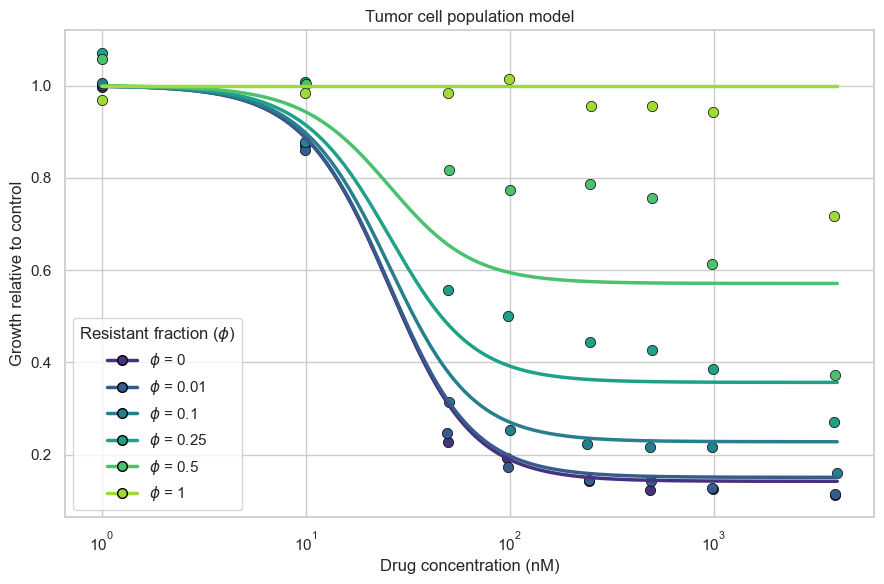

In [9]:
phi_values = sorted(df["Phi"].unique())

# Colors ---------------------------------
palette = sns.color_palette(
    "viridis",
    n_colors=len(phi_values)
)

phi_colors = dict(zip(phi_values, palette))

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(9, 6))


# model dose grid
dose_grid = np.logspace(
    np.log10(df["Dose"].min()),
    np.log10(df["Dose"].max()),
    500
)

for p in phi_values:
    subset = df[df["Phi"] == p]

    # Experimental data
    sns.scatterplot(
        data=subset,
        x="Dose",
        y="Growth Inhibition",
        color=phi_colors[p],
        s=55,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Model curve
    predicted_curve = model(
        dose_grid,
        p,
        Emax_t_fit,
        IC50_fit,
        h_fit
    )

    sns.lineplot(
        x=dose_grid,
        y=predicted_curve,
        color=phi_colors[p],
        linewidth=2.5,
        ax=ax
    )


# Axis labels and formatting ---------------------------
ax.set_xlabel("Drug concentration (nM)")
ax.set_xscale("log")
ax.set_ylabel("Growth relative to control")

ax.set_title(
    "Tumor cell population model"
)


# Legend --------------------------------------------

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color=phi_colors[p],
        markerfacecolor=phi_colors[p],
        markeredgecolor="black",
        linewidth=2.5,
        markersize=7,
        label=fr"$\phi$ = {p:g}"
    )
    for p in phi_values
]

ax.legend(
    handles=handles,
    title=r"Resistant fraction ($\phi$)"
)


plt.tight_layout()
plt.show()

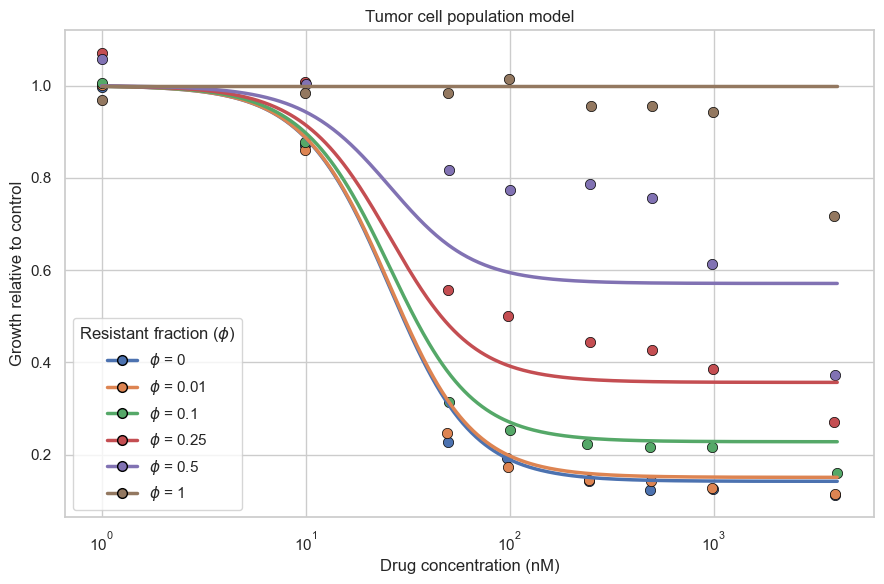

In [11]:
# (Same plot as above but using default categorical color scheme)

phi_values = sorted(df["Phi"].unique())

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

colors = sns.color_palette()

phi_colors = dict(zip(phi_values, colors))

fig, ax = plt.subplots(figsize=(9, 6))

dose_grid = np.logspace(
    np.log10(df["Dose"].min()),
    np.log10(df["Dose"].max()),
    500
)

for p in phi_values:
    subset = df[df["Phi"] == p]

    # Experimental data
    sns.scatterplot(
        data=subset,
        x="Dose",
        y="Growth Inhibition",
        color=phi_colors[p],
        s=55,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    # Model curve
    predicted_curve = model(
        dose_grid,
        p,
        Emax_t_fit,
        IC50_fit,
        h_fit
    )

    sns.lineplot(
        x=dose_grid,
        y=predicted_curve,
        color=phi_colors[p],
        linewidth=2.5,
        ax=ax
    )


# Axis labels and formatting --------------------
ax.set_xlabel("Drug concentration (nM)")
ax.set_xscale("log")
ax.set_ylabel("Growth relative to control")

ax.set_title(
    "Tumor cell population model"
)


# legend ------------------------------------------
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color=phi_colors[p],
        markerfacecolor=phi_colors[p],
        markeredgecolor="black",
        linewidth=2.5,
        markersize=7,
        label=fr"$\phi$ = {p:g}"
    )
    for p in phi_values
]

ax.legend(
    handles=handles,
    title=r"Resistant fraction ($\phi$)"
)


plt.tight_layout()
plt.show()

# Model that assumes resistant is also affected by drug (but less so)

The resistant population having its own IC50 and response gives the model flexibility to have another falloff point (steepness depending on h) of how/where we get another area of the dose response curve that reacts strongle to drug concentration because that is around the IC50R.

If $A_R = 0$, you get the first model

($A$ is just the product of $E_{max}$ and $t$)

This is not what we've been modeling so far

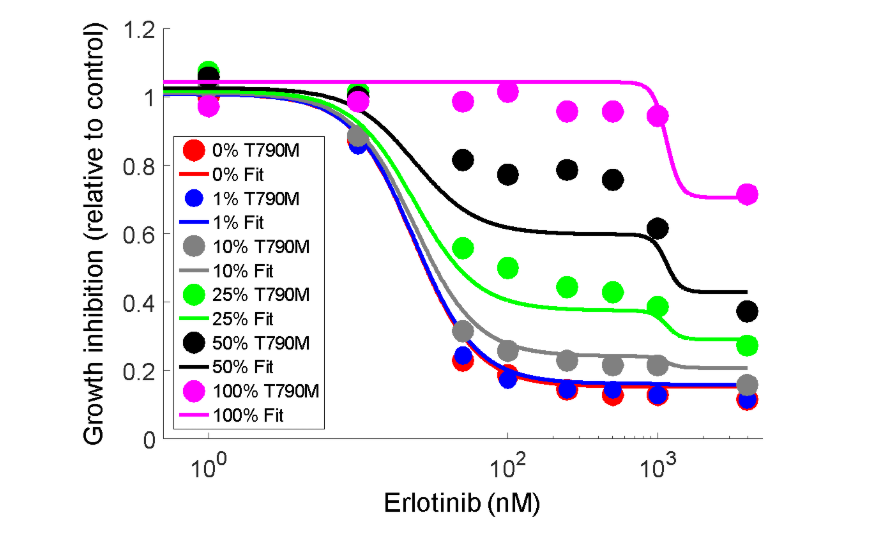

If you look at the pink data, you'll see a falloff right after $10^3$ concentration of drug. That proves there is an $IC50_R$ because $\phi=1$, therefore any drug response is solely from parameters based on the resistant population

## Load Data

In [12]:
data = pd.read_csv('./slide-6-data.csv')
data["Dose"] = 10**data["Dose"]

## Ectract Data

In [25]:
C = data["Dose"].to_numpy()
phi = data["Phi"].to_numpy()
Y_obs = data["Growth Inhibition"].to_numpy()

## Define Model

$D_S(C)=\frac{E_{max,S}C^{h_S}}{IC50^{h_S}_{S}+C^{h_S}}$

$D_R(C)=\frac{E_{max,R}C^{h_R}}{IC50^{h_R}_{R}+C^{h_R}}$

Model that is trained:

$Y(C,\phi)=(1-\phi)e^{-D_S(C)t}+\phi e^{-D_R(C)t}$

In [26]:
def model(params, C, phi):
    A_S, IC50_S, h_S, A_R, IC50_R, h_R = params

    # Drug-induced death effect in sensitive population
    effect_S = (
        A_S
        * C**h_S
        / (IC50_S**h_S + C**h_S)
    )

    # Drug-induced death effect in resistant population
    effect_R = (
        A_R
        * C**h_R
        / (IC50_R**h_R + C**h_R)
    )

    # Population response
    Y = (
        (1 - phi) * np.exp(-effect_S)
        +
        phi * np.exp(-effect_R)
    )

    return Y


## Residuals

In [15]:
def residuals(params):

    Y_pred = model(params, C, phi)

    return Y_pred - Y_obs

## Initial Guesses

In [16]:
initial_guess = [
    2.0,    # A_S = Emax_S * t
    50.0,   # IC50_S (nM)
    2.0,    # h_S

    0.5,    # A_R = Emax_R * t
    3000.0, # IC50_R (nM)
    2.0     # h_R
]

## Parameter Bounds

In [17]:
lower_bounds = [
    0.0,    # A_S
    0.001,  # IC50_S
    0.1,    # h_S

    0.0,    # A_R
    0.001,  # IC50_R
    0.1     # h_R
]

upper_bounds = [
    20.0,       # A_S
    1e6,        # IC50_S
    20.0,       # h_S

    20.0,       # A_R
    1e6,        # IC50_R
    20.0        # h_R
]

## Fit Model

In [18]:
fit = least_squares(
    residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=100000
)

## Extract Fitted Parameters

In [19]:
A_S, IC50_S, h_S, A_R, IC50_R, h_R = fit.x

print("\nFITTED PARAMETERS")
print("------------------")

print(f"A_S      = {A_S:.6f}")
print(f"IC50_S   = {IC50_S:.6f} nM")
print(f"h_S      = {h_S:.6f}")

print()

print(f"A_R      = {A_R:.6f}")
print(f"IC50_R   = {IC50_R:.6f} nM")
print(f"h_R      = {h_R:.6f}")


FITTED PARAMETERS
------------------
A_S      = 1.859699
IC50_S   = 37.650499 nM
h_S      = 2.038496

A_R      = 0.380317
IC50_R   = 1120.746328 nM
h_R      = 20.000000


## Calculate Predictions

In [20]:
data["Prediction"] = model(
    fit.x,
    C,
    phi
)

## Calculate Goodness of Fit

In [21]:
residual = Y_obs - data["Prediction"].to_numpy()

SSE = np.sum(residual**2)

RMSE = np.sqrt(
    np.mean(residual**2)
)

SST = np.sum(
    (Y_obs - np.mean(Y_obs))**2
)

R2 = 1 - SSE / SST

print("\nGOODNESS OF FIT")
print("----------------")

print(f"SSE  = {SSE:.6f}")
print(f"RMSE = {RMSE:.6f}")
print(f"R²   = {R2:.6f}")


GOODNESS OF FIT
----------------
SSE  = 0.219938
RMSE = 0.067691
R²   = 0.963487


## Smooth Dose Curve Predictions

In [22]:
dose_grid = np.logspace(
    np.log10(C.min()),
    np.log10(C.max()),
    500
)

## Plot predictions

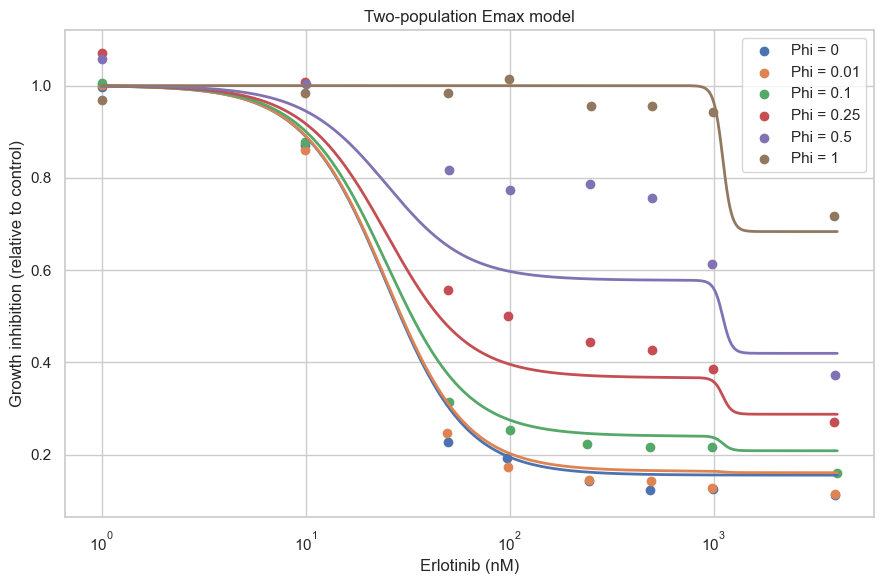

In [23]:
plt.figure(figsize=(9, 6))

for phi_value in sorted(data["Phi"].unique()):

    subset = data[data["Phi"] == phi_value]

    # Experimental points
    plt.scatter(
        subset["Dose"],
        subset["Growth Inhibition"],
        label=f"Phi = {phi_value:g}"
    )

    # Model prediction
    prediction = model(
        fit.x,
        dose_grid,
        np.full_like(dose_grid, phi_value)
    )

    plt.plot(
        dose_grid,
        prediction,
        linewidth=2
    )


plt.xscale("log")

plt.xlabel("Erlotinib (nM)")
plt.ylabel("Growth inhibition (relative to control)")

plt.title("Two-population Emax model")

plt.legend()

plt.tight_layout()

plt.show()